In [1]:
import os
from importlib.util import find_spec
from IPython import get_ipython

IN_VSCODE = bool(os.environ.get('VSCODE_PID'))
if IN_VSCODE:
    PREFERRED_MATPLOTLIB_BACKENDS = [('widget', 'module://ipympl.backend_nbagg'), ('qt', 'qt'), ('notebook', 'notebook')]
else:
    PREFERRED_MATPLOTLIB_BACKENDS = [('widget', 'module://ipympl.backend_nbagg'), ('notebook', 'notebook'), ('qt', 'qt')]
ip = get_ipython()
if IN_VSCODE:
    print('VS Code detected; trying %matplotlib widget first, then falling back to qt/notebook if needed')

for MATPLOTLIB_BACKEND, MATPLOTLIB_MAGIC_ARG in PREFERRED_MATPLOTLIB_BACKENDS:
    if MATPLOTLIB_BACKEND == 'widget' and find_spec('ipympl') is None:
        print("ipympl is not installed; skipping %matplotlib widget")
        continue
    try:
        if MATPLOTLIB_BACKEND == 'widget':
            import ipympl
        ip.run_line_magic('matplotlib', MATPLOTLIB_MAGIC_ARG)
        print(f"Using %matplotlib {MATPLOTLIB_BACKEND}")
        break
    except Exception as exc:
        print(f"Failed to enable %matplotlib {MATPLOTLIB_BACKEND}: {exc}")
else:
    MATPLOTLIB_BACKEND = 'inline'
    ip.run_line_magic('matplotlib', MATPLOTLIB_BACKEND)
    print("Falling back to %matplotlib inline")

import sys
print(sys.executable)
print(sys.version)
import matplotlib
print(matplotlib.get_backend())


VS Code detected; trying %matplotlib widget first, then falling back to qt/notebook if needed
Using %matplotlib widget
/home/dina/miniforge3/bin/python
3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]
module://ipympl.backend_nbagg


In [2]:
from getgrid import getgrid
from pathlib import Path
from data_paths import grid_dir
_, _, _, z, _, _, _ = getgrid(base_dir=Path(grid_dir))

In [3]:
from pathlib import Path

from data_paths import AW_DIR, BIOEXP

import importlib
import numpy as np
import phyto_sibciom
import vert_profile

importlib.reload(vert_profile)
importlib.reload(phyto_sibciom)

from phyto_sibciom import (
    compute_shared_color_limits,
    inspect_nc,
    make_file_path,
    plot_field_from_click,
    plot_linked_fields_from_click,
    prepare_sibciom_3dvar,
)
from vert_profile import compute_aw_fields, convert_aw_units, prepare_aw_3dvar

# Observed field parameters
AW_MODE = 'mmol'  # cells = cells/m3; mmol = mmolC/m3 or mmolN/m3
MMOL_BASIS = 'C'  # Used only when AW_MODE == 'mmol': C or N
#    формула перевода: Aw_mmolC = Aw_cells * mg_c_per_cell / mg_c_per_mmol_c

AW_MG_C_PER_CELL = 2726e-9  # Conversion from cells to mg C per cell
MG_C_PER_MMOL_C = 12.011  # Mass of 1 mmol of carbon in mg C
N_PER_C_MOLAR = 16.0 / 106.0  # Molar N/C ratio 
AW_YEAR = 2017   
MONTH = 8  
AW_DAY = 10  
LIGHT_SCHEME = 'jerlov_two_component'  # 'beer_chl' or 'jerlov_two_component'
JERLOV_TYPE = 1  # Jerlov water type from forcing.F table
JERLOV_P = None  # Override component weight; None uses table value
JERLOV_LAMBDA1 = None  # Override fast attenuation coefficient
JERLOV_LAMBDA2 = None  # Override slow attenuation coefficient
JERLOV_LAMBDA_UNITS = 'cm^-1'  # Forcing.F coefficients are in cm^-1
LEVEL = 3  # Vertical level index for 2d-maps
NLEV = 12  # Number of profile levels.  None means all levels
INITIAL_I = 118  
INITIAL_J = 107  

# SibCIOM parameters
DATA_DIR = BIOEXP  # Directory with monthly model NetCDF files
VAR_NAME = 'phyto'   # Model variable to plot
SNAP_YEAR = 2017  #
SNAP_MONTH = MONTH  
NC_INFO = False  # Print NetCDF structure before plotting


In [4]:
result = compute_aw_fields(
    year=AW_YEAR,
    month=MONTH,
    day=AW_DAY,
    base_dir=AW_DIR,
    light_scheme=LIGHT_SCHEME,
    jerlov_type=JERLOV_TYPE,
    jerlov_p=JERLOV_P,
    jerlov_lambda1=JERLOV_LAMBDA1,
    jerlov_lambda2=JERLOV_LAMBDA2,
    jerlov_lambda_units=JERLOV_LAMBDA_UNITS,
)
obs_field = result['Aw']  # replace 'Aw' with 'chl' or 'Iz' if needed
# obs_field =  result['chl']

In [5]:

if obs_field['field_key'] == 'Aw': 
    obs_field = convert_aw_units(
        obs_field,
        mode=AW_MODE,
        mmol_basis=MMOL_BASIS,
        mg_c_per_cell=AW_MG_C_PER_CELL,
        mg_c_per_mmol_c=MG_C_PER_MMOL_C,
        n_per_c_molar=N_PER_C_MOLAR,
    )

obs = prepare_aw_3dvar(obs_field)

phyto = prepare_sibciom_3dvar(
    data_dir=DATA_DIR,
    year=SNAP_YEAR,
    month=SNAP_MONTH,
    var_name=VAR_NAME,
    grid_base_dir=AW_DIR,
)

common_vmin, common_vmax = compute_shared_color_limits(
    np.asarray(obs['var_3d'])[:, :, LEVEL],
    np.asarray(phyto['var_3d'])[:, :, LEVEL],
)
common_vmin, common_vmax = 0, 4
plot_common_kwargs = {
    'map_level': LEVEL,
    'profile_nlev': NLEV,
    'map_vmin': common_vmin,
    'map_vmax': common_vmax,
}

def prefix_kwargs(prefix, kwargs):
    return {f'{prefix}{key}': value for key, value in kwargs.items()}

obs_field_kwargs = {
    'var': np.asarray(obs['var_3d']),
    'z_levels': np.asarray(obs['levels']),
    'year': AW_YEAR,
    'month': MONTH,
    'var_name': str(obs['var_name']),
    'var_units': str(obs['var_units']),
}

phyto_field_kwargs = {
    'var': np.asarray(phyto['var_3d']),
    'z_levels': np.asarray(phyto['levels']),
    'year': SNAP_YEAR,
    'month': SNAP_MONTH,
    'var_name': VAR_NAME,
    'var_units': str(phyto['units']),
}


In [6]:
INITIAL_I=250
INITIAL_J=300
INITIAL_I,INITIAL_J

(250, 300)

In [7]:

if obs_field['field_key'] == 'Aw': 
    obs_field = convert_aw_units(
        obs_field,
        mode=AW_MODE,
        mmol_basis=MMOL_BASIS,
        mg_c_per_cell=AW_MG_C_PER_CELL,
        mg_c_per_mmol_c=MG_C_PER_MMOL_C,
        n_per_c_molar=N_PER_C_MOLAR,
    )

obs = prepare_aw_3dvar(obs_field)

phyto = prepare_sibciom_3dvar(
    data_dir=DATA_DIR,
    year=SNAP_YEAR,
    month=SNAP_MONTH,
    var_name=VAR_NAME,
    grid_base_dir=AW_DIR,
)

common_vmin, common_vmax = compute_shared_color_limits(
    np.asarray(obs['var_3d'])[:, :, LEVEL],
    np.asarray(phyto['var_3d'])[:, :, LEVEL],
)
common_vmin, common_vmax = 0, 4
plot_common_kwargs = {
    'map_level': LEVEL,
    'profile_nlev': NLEV,
    'map_vmin': common_vmin,
    'map_vmax': common_vmax,
}

def prefix_kwargs(prefix, kwargs):
    return {f'{prefix}{key}': value for key, value in kwargs.items()}

obs_field_kwargs = {
    'var': np.asarray(obs['var_3d']),
    'z_levels': np.asarray(obs['levels']),
    'year': AW_YEAR,
    'month': MONTH,
    'var_name': str(obs['var_name']),
    'var_units': str(obs['var_units']),
}

phyto_field_kwargs = {
    'var': np.asarray(phyto['var_3d']),
    'z_levels': np.asarray(phyto['levels']),
    'year': SNAP_YEAR,
    'month': SNAP_MONTH,
    'var_name': VAR_NAME,
    'var_units': str(phyto['units']),
}


In [8]:
# selected_file = make_file_path(BIOEXP, SNAP_YEAR, SNAP_MONTH)
# print(f'Selected file: {selected_file}')
# if NC_INFO:
#     inspect_nc(selected_file)

# obs_i, obs_j = plot_field_from_click(
#     i=INITIAL_I,
#     j=INITIAL_J,
#     **obs_field_kwargs,
#     **plot_common_kwargs,
# )

# phyto_i, phyto_j = plot_field_from_click(
#     i=obs_i,
#     j=obs_j,
#     **phyto_field_kwargs,
#     **plot_common_kwargs,
# )

# print(f"{obs['var_name']} point: i={obs_i}, j={obs_j}")
# print(f'SibCIOM point: i={phyto_i}, j={phyto_j}')


Selected file: /media/dina/data4tb/SibCIOM/Test/Output/ocn/mth2017-08.nc
Notebook widget backend detected, but Qt backend could not be enabled for blocking point selection.
  qtagg: Failed to import any of the following Qt binding modules: PyQt6, PySide6, PyQt5, PySide2
  qt5agg: Failed to import any of the following Qt binding modules: PyQt5, PySide2
  qtcairo: cairo backend requires that pycairo>=1.14.0 or cairocffi is installed
Using matplotlib backend module://ipympl.backend_nbagg. Click once on either map to select a shared point.


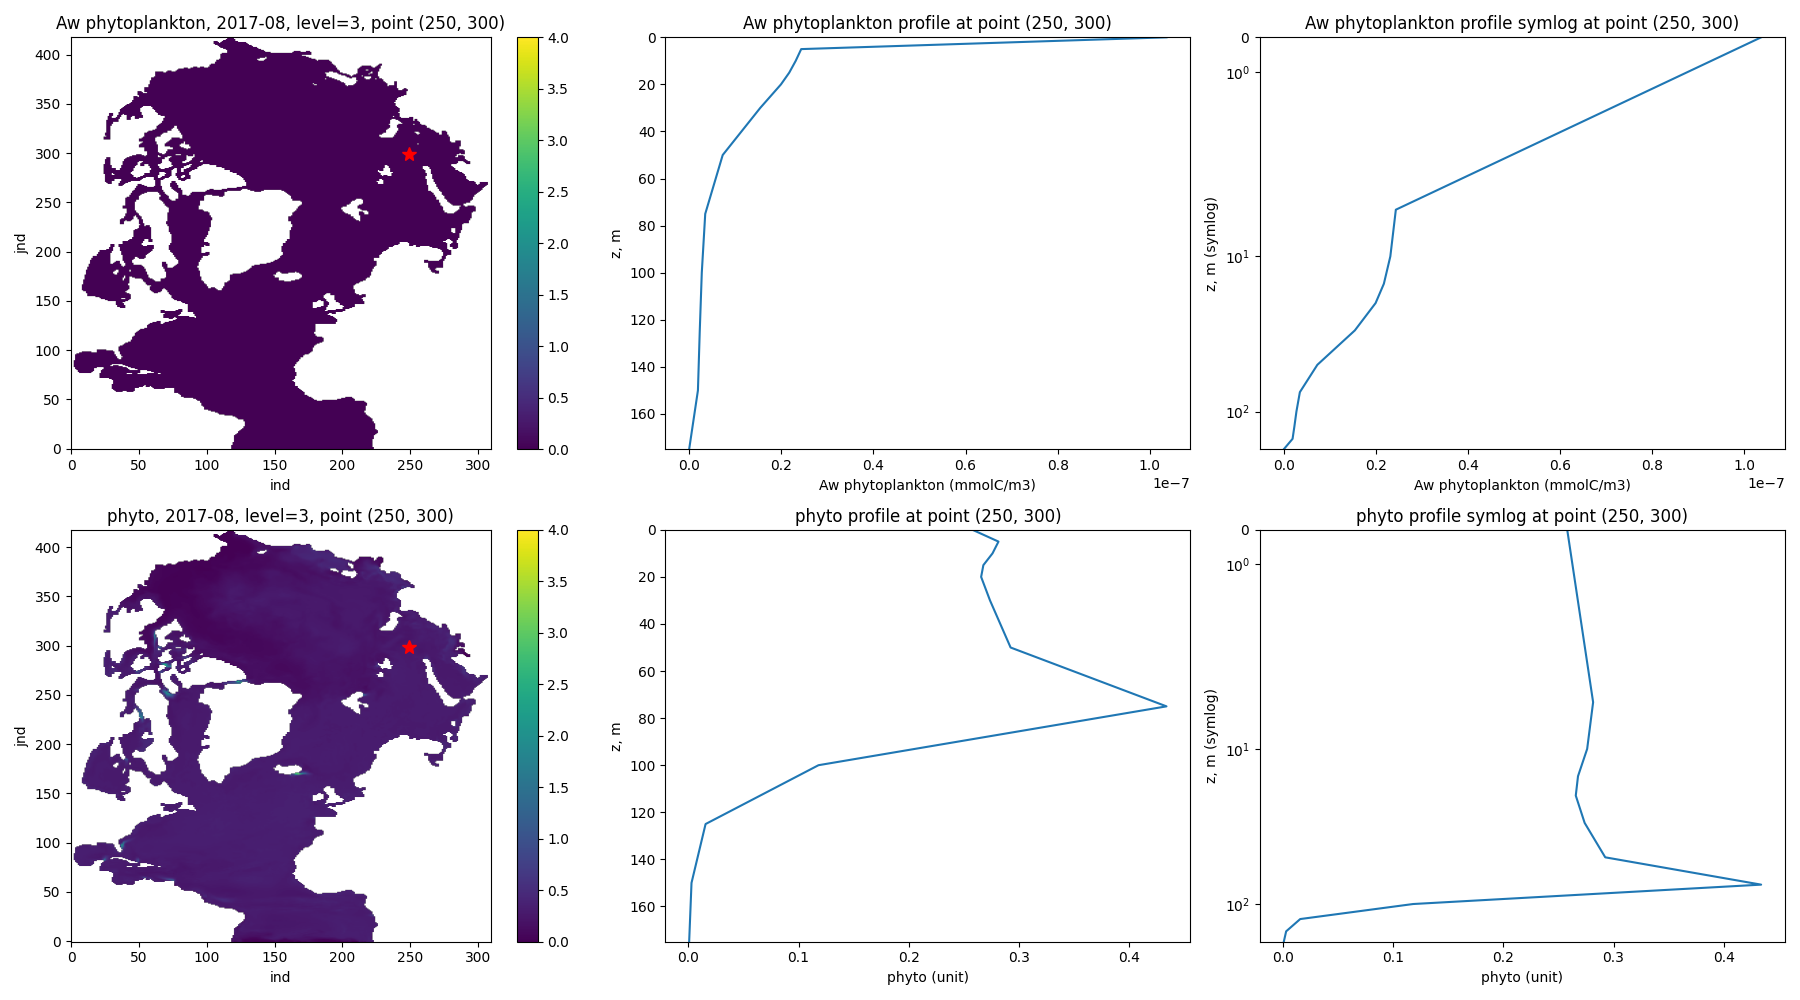

In [ ]:
selected_file = make_file_path(BIOEXP, SNAP_YEAR, SNAP_MONTH)
print(f'Selected file: {selected_file}')
if NC_INFO:
    inspect_nc(selected_file)

obs_point, phyto_point = plot_linked_fields_from_click(
    i=INITIAL_I,
    j=INITIAL_J,
    **prefix_kwargs('left_', obs_field_kwargs),
    **prefix_kwargs('right_', phyto_field_kwargs),
    **plot_common_kwargs,
)

print(f"{obs['var_name']} point: i={obs_point[0]}, j={obs_point[1]}")
print(f'SibCIOM point: i={phyto_point[0]}, j={phyto_point[1]}')


python_executable: c:\Users\One\AppData\Local\Programs\Python\Python312\python.exe
python_version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
platform: Windows-10-10.0.19045-SP0
ipython_shell: ZMQInteractiveShell
IPython: 9.12.0
matplotlib: 3.10.8
matplotlib_backend: module://ipympl.backend_nbagg
interactive_expected: False
ipywidgets: 8.1.8
ipympl: 0.10.0
jupyterlab: NOT INSTALLED
notebook: NOT INSTALLED
jupyter_server: NOT INSTALLED
jupyterlab_widgets: 3.0.16
widgetsnbextension: 4.0.15
MPLBACKEND_env: module://matplotlib_inline.backend_inline
canvas_type: Canvas
callback_id: 15


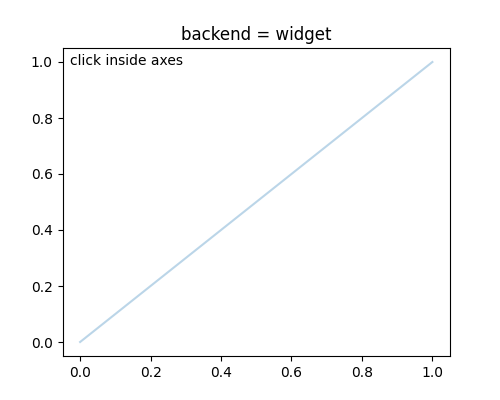

In [ ]:
from IPython import get_ipython
import sys
import os
import platform
from importlib.metadata import version, PackageNotFoundError

import IPython
import matplotlib
import ipywidgets

def pkg_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "NOT INSTALLED"

print("python_executable:", sys.executable)
print("python_version:", sys.version.replace("\n", " "))
print("platform:", platform.platform())

shell = get_ipython()
print("ipython_shell:", type(shell).__name__ if shell else None)
print("IPython:", IPython.__version__)

print("matplotlib:", matplotlib.__version__)
print("matplotlib_backend:", matplotlib.get_backend())
print("interactive_expected:", "inline" not in matplotlib.get_backend().lower() and "agg" not in matplotlib.get_backend().lower())

print("ipywidgets:", getattr(ipywidgets, "__version__", "unknown"))
print("ipympl:", pkg_version("ipympl"))
print("jupyterlab:", pkg_version("jupyterlab"))
print("notebook:", pkg_version("notebook"))
print("jupyter_server:", pkg_version("jupyter_server"))
print("jupyterlab_widgets:", pkg_version("jupyterlab_widgets"))
print("widgetsnbextension:", pkg_version("widgetsnbextension"))

print("MPLBACKEND_env:", os.environ.get("MPLBACKEND"))
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "widget")  # или "notebook", если widget не работает

import matplotlib
import matplotlib.pyplot as plt

clicks = []

fig, ax = plt.subplots(figsize=(5, 4))
ax.set_title(f"backend = {matplotlib.get_backend()}")
ax.plot([0, 1], [0, 1], alpha=0.3)

marker, = ax.plot([], [], "r*", ms=14)
text = ax.text(0.02, 0.98, "click inside axes", transform=ax.transAxes, va="top")

def on_click(event):
    if event.inaxes is not ax or event.xdata is None or event.ydata is None:
        return
    clicks.append((event.xdata, event.ydata))
    marker.set_data([event.xdata], [event.ydata])
    text.set_text(f"last click: ({event.xdata:.2f}, {event.ydata:.2f})\ncount={len(clicks)}")
    fig.canvas.draw_idle()
    print("CLICK:", event.xdata, event.ydata)

cid = fig.canvas.mpl_connect("button_press_event", on_click)

print("canvas_type:", type(fig.canvas).__name__)
print("callback_id:", cid)

plt.show()